# 전국 공간 데이터 EDA (기초 EDA)

- **분석 대상**: 전국 산불 발생 위치와 지형, 등산로, 임도, 산불소화시설, 소방서, 소방용수시설, 토지피복도 공간 데이터.
- **이번 노트북의 범위**: 원천 데이터 구조 확인, 공간 피처 생성/캐시 로드, 변수군별 기초 EDA, 시각화 기반 패턴 확인.
- **비교 축**: `is_gangwon` 기준 강원도 산불과 타 지역 산불을 대조하되, 변수별 유효 표본 수를 항상 함께 확인한다.

In [1]:
# 라이브러리 및 한글 폰트 설정
import sys, os, re
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_path = 'C:/Windows/Fonts/malgun.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme(
    style='whitegrid',
    font=font_name,
    rc={
        'font.family': font_name,
        'font.sans-serif': [font_name],
        'axes.unicode_minus': False
    }
)
plt.rcParams['font.family'] = font_name
plt.rcParams['font.sans-serif'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
print('matplotlib 한글 폰트 설정 완료:', plt.rcParams['font.family'])


matplotlib 한글 폰트 설정 완료: ['Malgun Gothic']


In [2]:
# 데이터 경로 설정
BASE_DIR = Path('D:/farm-system-public-02')
DATA_DIR = BASE_DIR / 'data'
SPATIAL_DIR = DATA_DIR / '산불_공간DB'

FIRE_PATH = DATA_DIR / '산불_전국/산불발생위치도_전국.csv'
TOPO_PATH = SPATIAL_DIR / '산불발생위치도_지형특성계산.csv'
FACILITY_PATH = SPATIAL_DIR / '전국_산불소화시설.csv'
STATION_PATH = SPATIAL_DIR / '전국_소방서_좌표.csv'
WATER_PATH = SPATIAL_DIR / '전국_소방용수시설.csv'
ROAD_PATH = SPATIAL_DIR / '전국_임도망도.csv'
TRAIL_PATH = SPATIAL_DIR / '전국_등산로.csv'
LANDCOVER_DIR = SPATIAL_DIR / '산불발생_토지피복도'


## 1. 원천 공간 데이터 구조 확인

분석 및 시각화 코드를 작성하기 전에 각 원천 파일의 컬럼, 타입, 지역명 후보, 좌표 컬럼, 공간좌표 저장 방식을 먼저 확인한다. 대용량 CSV는 전체 로드 전에 샘플만 확인한다.

In [3]:
# 원천 데이터 파일 구조 샘플 확인
csv_paths = {
    '산불발생위치도_전국': FIRE_PATH,
    '지형특성계산': TOPO_PATH,
    '전국_등산로': TRAIL_PATH,
    '전국_산불소화시설': FACILITY_PATH,
    '전국_소방서_좌표': STATION_PATH,
    '전국_소방용수시설': WATER_PATH,
    '전국_임도망도': ROAD_PATH,
}

for name, path in csv_paths.items():
    print('\n' + '=' * 90)
    print(f'[{name}]')
    print(f'경로: {path}')
    print(f'존재 여부: {path.exists()}')
    if path.exists():
        print(f'파일 크기(MB): {path.stat().st_size / 1024 / 1024:.2f}')
        sample = pd.read_csv(path, encoding='utf-8-sig', nrows=5)
        print(f'샘플 shape: {sample.shape}')
        print('컬럼 목록:')
        print(list(sample.columns))
        print('샘플 dtypes:')
        print(sample.dtypes.astype(str).to_string())

landcover_files = sorted(LANDCOVER_DIR.glob('*.gpkg'))
print('\n' + '=' * 90)
print('[토지피복도 GPKG]')
print(f'디렉터리: {LANDCOVER_DIR}')
print(f'파일 수: {len(landcover_files)}')
print('파일 예시:', [p.name for p in landcover_files[:10]])



[산불발생위치도_전국]
경로: D:\farm-system-public-02\data\산불_전국\산불발생위치도_전국.csv
존재 여부: True
파일 크기(MB): 2.89
샘플 shape: (5, 16)
컬럼 목록:
['fire_id', '연도', '월', '일', '시간', '진화소요시간(HH)', '위도', '경도', '발생지역시도명', '발생지역시군구명', '발생지역읍면동명', '발생지역리명', '발생지역번지', '발생원인명', '피해면적(ha)', '피해금액']
샘플 dtypes:
fire_id           str
연도              int64
월               int64
일               int64
시간              int64
진화소요시간(HH)    float64
위도            float64
경도            float64
발생지역시도명           str
발생지역시군구명          str
발생지역읍면동명          str
발생지역리명        float64
발생지역번지            str
발생원인명             str
피해면적(ha)      float64
피해금액          float64

[지형특성계산]
경로: D:\farm-system-public-02\data\산불_공간DB\산불발생위치도_지형특성계산.csv
존재 여부: True
파일 크기(MB): 3.37
샘플 shape: (5, 9)
컬럼 목록:
['fire_id', '위도', '경도', '고도(m)', '경사도(도)', '사면방향_sin', '사면방향_cos', 'TPI(지형위치지수)', 'TWI(지형다습지수)']
샘플 dtypes:
fire_id            str
위도             float64
경도             float64
고도(m)          float64
경사도(도)         float64
사면방향_sin       float64
사면

In [4]:
# 지역명, 좌표, 공간좌표 관련 컬럼 후보 확인
keywords = ['시도', '시군', '행정구역', '발생지역', '위도', '경도', '좌표', '공간']

for name, path in csv_paths.items():
    if not path.exists():
        continue
    sample = pd.read_csv(path, encoding='utf-8-sig', nrows=1000)
    candidate_cols = [c for c in sample.columns if any(k in str(c) for k in keywords)]
    print('\n' + '=' * 90)
    print(f'[{name}] 지역/좌표 후보 컬럼')
    print(candidate_cols)
    for col in candidate_cols:
        nunique = sample[col].nunique(dropna=True)
        examples = []
        for value in sample[col].dropna().astype(str).head(5):
            examples.append(value[:120] + ('...' if len(value) > 120 else ''))
        print(f'  - {col}: unique(sample)={nunique}, 예시={examples}')



[산불발생위치도_전국] 지역/좌표 후보 컬럼
['위도', '경도', '발생지역시도명', '발생지역시군구명', '발생지역읍면동명', '발생지역리명', '발생지역번지']
  - 위도: unique(sample)=851, 예시=['37.63510045170228', '37.4507925535295', '37.68129016655618', '37.502707074583576', '37.61738177694373']
  - 경도: unique(sample)=851, 예시=['126.99758205559452', '127.06916827308488', '127.01696540439966', '127.1476360866065', '127.03749420632153']
  - 발생지역시도명: unique(sample)=4, 예시=['서울특별시', '서울특별시', '서울특별시', '서울특별시', '서울특별시']
  - 발생지역시군구명: unique(sample)=71, 예시=['강북구', '서초구', '도봉구', '송파구', '강북']
  - 발생지역읍면동명: unique(sample)=250, 예시=['수유동', '내곡동', '도봉동', '마천동', '미아']
  - 발생지역리명: unique(sample)=60, 예시=['덕선리', '오', '청강리', '청강리', '오']
  - 발생지역번지: unique(sample)=541, 예시=['산127-1', '산12-415', '산29-89', '54-20', '산35-3']

[지형특성계산] 지역/좌표 후보 컬럼
['위도', '경도']
  - 위도: unique(sample)=851, 예시=['37.63510045170228', '37.4507925535295', '37.68129016655618', '37.502707074583576', '37.61738177694373']
  - 경도: unique(sample)=851, 예시=['126.99758205559452', '127.06916827308488', '127.0

## 2. 공간 피처 연산 및 캐시 로드

산불 발생 지점을 기준으로 지형 특성, 시설물 최단거리, 등산로/임도 속성, 300m 반경 토지피복 비율을 결합한다. 캐시가 존재하면 대용량 KDTree 및 GPKG 연산을 건너뛰고 `fire_spatial_features.csv`를 로드한다.

In [5]:
# 공간 데이터 연산 파이프라인 및 캐싱
CACHE_PATH = BASE_DIR / 'jsw/EDA/fire_spatial_features.csv'

def latlon_to_3d(lat, lon):
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)
    return np.column_stack((x, y, z))

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = np.sin(dlat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

wkt_re = re.compile(r'[-+]?\d*\.\d+|\d+')
def parse_wkt_points(wkt_str):
    if not isinstance(wkt_str, str):
        return []
    numbers = [float(x) for x in wkt_re.findall(wkt_str)]
    points = []
    for i in range(0, len(numbers) - 1, 2):
        points.append((numbers[i+1], numbers[i]))
    return points

if not CACHE_PATH.exists():
    print('캐시 파일이 존재하지 않아 공간 피처 연산을 시작합니다...')
    fire_df = pd.read_csv(FIRE_PATH, encoding='utf-8-sig')
    topo_df = pd.read_csv(TOPO_PATH, encoding='utf-8-sig')
    merged_df = pd.merge(fire_df, topo_df, on='fire_id', how='inner')
    fire_coords = latlon_to_3d(merged_df['위도'].values, merged_df['경도'].values)
    
    # 1. 소방서 매칭
    station_df = pd.read_csv(STATION_PATH, encoding='utf-8-sig')
    station_coords = latlon_to_3d(station_df['위도'].values, station_df['경도'].values)
    station_tree = KDTree(station_coords)
    dists, idxs = station_tree.query(fire_coords)
    merged_df['nearest_station_dist_km'] = haversine_distance(
        merged_df['위도'].values, merged_df['경도'].values,
        station_df['위도'].values[idxs], station_df['경도'].values[idxs])
    merged_df['nearest_station_name'] = station_df['소방서 및 안전센터명'].values[idxs]
    
    # 2. 산불소화시설 매칭
    facility_df = pd.read_csv(FACILITY_PATH, encoding='utf-8-sig')
    facility_coords = latlon_to_3d(facility_df['위도'].values, facility_df['경도'].values)
    facility_tree = KDTree(facility_coords)
    dists_fac, idxs_fac = facility_tree.query(fire_coords)
    merged_df['nearest_facility_dist_km'] = haversine_distance(
        merged_df['위도'].values, merged_df['경도'].values,
        facility_df['위도'].values[idxs_fac], facility_df['경도'].values[idxs_fac])
    merged_df['nearest_facility_remote'] = facility_df['원격제어'].values[idxs_fac]
    
    # 3. 소방용수시설 매칭
    water_df = pd.read_csv(WATER_PATH, encoding='utf-8-sig')
    water_coords = latlon_to_3d(water_df['위도'].values, water_df['경도'].values)
    water_tree = KDTree(water_coords)
    dists_wat, idxs_wat = water_tree.query(fire_coords)
    merged_df['nearest_water_dist_km'] = haversine_distance(
        merged_df['위도'].values, merged_df['경도'].values,
        water_df['위도'].values[idxs_wat], water_df['경도'].values[idxs_wat])
    
    # 4. 임도망 매칭
    road_df = pd.read_csv(ROAD_PATH, encoding='utf-8-sig')
    road_vertices, road_row_idxs = [], []
    for idx, row in road_df.iterrows():
        pts = parse_wkt_points(row['공간좌표'])
        for pt in pts:
            road_vertices.append(pt)
            road_row_idxs.append(idx)
    road_vertices = np.array(road_vertices)
    road_row_idxs = np.array(road_row_idxs)
    road_3d = latlon_to_3d(road_vertices[:, 0], road_vertices[:, 1])
    road_tree = KDTree(road_3d)
    dists_road, idxs_road = road_tree.query(fire_coords)
    nearest_road_row_idxs = road_row_idxs[idxs_road]
    merged_df['nearest_road_dist_km'] = haversine_distance(
        merged_df['위도'].values, merged_df['경도'].values,
        road_vertices[idxs_road, 0], road_vertices[idxs_road, 1])
    merged_df['nearest_road_width_m'] = road_df['폭(m)'].values[nearest_road_row_idxs]
    merged_df['nearest_road_length_km'] = road_df['도형길이'].values[nearest_road_row_idxs] / 1000.0
    
    # 5. 등산로 매칭
    trail_df = pd.read_csv(TRAIL_PATH, encoding='utf-8-sig')
    trail_vertices, trail_row_idxs = [], []
    for idx, row in trail_df.iterrows():
        pts = parse_wkt_points(row['공간좌표'])
        for pt in pts:
            trail_vertices.append(pt)
            trail_row_idxs.append(idx)
    trail_vertices = np.array(trail_vertices)
    trail_row_idxs = np.array(trail_row_idxs)
    trail_3d = latlon_to_3d(trail_vertices[:, 0], trail_vertices[:, 1])
    trail_tree = KDTree(trail_3d)
    dists_trail, idxs_trail = trail_tree.query(fire_coords)
    nearest_trail_row_idxs = trail_row_idxs[idxs_trail]
    merged_df['nearest_trail_dist_km'] = haversine_distance(
        merged_df['위도'].values, merged_df['경도'].values,
        trail_vertices[idxs_trail, 0], trail_vertices[idxs_trail, 1])
    merged_df['nearest_trail_difficulty'] = trail_df['등산로난이도명'].values[nearest_trail_row_idxs]
    merged_df['nearest_trail_material'] = trail_df['등산로재질내용'].values[nearest_trail_row_idxs]
    
    # 6. 토지피복도 매칭
    lc_provinces = [f.name for f in LANDCOVER_DIR.glob('*.gpkg')]
    lc_list = []
    for province_file in lc_provinces:
        df_lc = gpd.read_file(LANDCOVER_DIR / province_file, ignore_geometry=True)
        pivot_dae = df_lc.pivot_table(index='산불ID', columns='대분류명', values='면적_제곱미터', aggfunc='sum', fill_value=0).reset_index()
        forest_df = df_lc[df_lc['중분류명'].isin(['침엽수림', '활엽수림', '혼효림'])]
        if not forest_df.empty:
            pivot_jung = forest_df.pivot_table(index='산불ID', columns='중분류명', values='면적_제곱미터', aggfunc='sum', fill_value=0).reset_index()
            pivot_province = pd.merge(pivot_dae, pivot_jung, on='산불ID', how='outer').fillna(0)
        else:
            pivot_province = pivot_dae
        lc_list.append(pivot_province)
    
    lc_all = pd.concat(lc_list, ignore_index=True).fillna(0).groupby('산불ID').sum().reset_index()
    merged_df = pd.merge(merged_df, lc_all, left_on='fire_id', right_on='산불ID', how='left').fillna(0)
    
    dae_cols = ['초지', '습지', '나지', '산림지역', '수역', '농업지역', '시가화건조지역']
    dae_cols_present = [c for c in dae_cols if c in merged_df.columns]
    merged_df['total_lc_area'] = merged_df[dae_cols_present].sum(axis=1)
    merged_df['total_lc_area_norm'] = merged_df['total_lc_area'].replace(0, 282743)
    
    landcover_cols = [c for c in lc_all.columns if c != '산불ID']
    for col in landcover_cols:
        merged_df[f'{col}_ratio'] = merged_df[col] / merged_df['total_lc_area_norm']
        
    if '산불ID' in merged_df.columns:
        merged_df = merged_df.drop(columns=['산불ID'])
        
    merged_df['is_gangwon'] = merged_df['발생지역시도명'].isin(['강원특별자치도', '강원도'])
    merged_df.to_csv(CACHE_PATH, index=False, encoding='utf-8-sig')
    print('공간 피처 연산 및 캐싱 파일 저장 완료!')
else:
    print('캐시 파일이 존재하므로 로드합니다.')
    merged_df = pd.read_csv(CACHE_PATH, encoding='utf-8-sig')
    print(f'로드 완료. 데이터 형태: {merged_df.shape}')


캐시 파일이 존재하므로 로드합니다.
로드 완료. 데이터 형태: (25036, 60)


## 3. 결합 피처 데이터 프로파일링

공간 피처가 결합된 `merged_df`의 전체 표본 수, 강원도/타 지역 표본 수, 변수군별 결측률과 유효 표본 수를 확인한다. 결측이 있는 변수는 해당 변수의 유효 행만 사용해 이후 EDA를 진행한다.

In [6]:
# 결합 데이터 기본 구조
print(f'전체 산불 건수: {len(merged_df):,}')
print(f'전체 컬럼 수: {merged_df.shape[1]:,}')
print(f'강원도 건수: {merged_df["is_gangwon"].sum():,} ({merged_df["is_gangwon"].mean()*100:.1f}%)')
print(f'타 지역 건수: {(~merged_df["is_gangwon"]).sum():,}')
print()

feature_groups = {
    '지형': ['고도(m)', '경사도(도)', '사면방향_sin', '사면방향_cos', 'TPI(지형위치지수)', 'TWI(지형다습지수)'],
    '시설물 거리': ['nearest_station_dist_km', 'nearest_water_dist_km', 'nearest_facility_dist_km', 'nearest_trail_dist_km', 'nearest_road_dist_km'],
    '임도/등산로 속성': ['nearest_road_width_m', 'nearest_road_length_km', 'nearest_trail_difficulty', 'nearest_trail_material'],
    '토지피복 대분류': ['산림지역_ratio', '농업지역_ratio', '초지_ratio', '습지_ratio', '나지_ratio', '수역_ratio', '시가화건조지역_ratio'],
    '산림 수종': ['침엽수림_ratio', '활엽수림_ratio', '혼효림_ratio'],
}

rows = []
for group, cols in feature_groups.items():
    for col in cols:
        if col not in merged_df.columns:
            continue
        rows.append({
            '변수군': group,
            '변수': col,
            '전체 유효 N': int(merged_df[col].notna().sum()),
            '강원 유효 N': int(merged_df.loc[merged_df['is_gangwon'], col].notna().sum()),
            '타지역 유효 N': int(merged_df.loc[~merged_df['is_gangwon'], col].notna().sum()),
            '결측률(%)': round(merged_df[col].isna().mean() * 100, 2),
            'dtype': str(merged_df[col].dtype),
        })

validity_df = pd.DataFrame(rows)
print(validity_df.to_string(index=False))


전체 산불 건수: 25,036
전체 컬럼 수: 60
강원도 건수: 4,139 (16.5%)
타 지역 건수: 20,897

      변수군                       변수  전체 유효 N  강원 유효 N  타지역 유효 N  결측률(%)   dtype
       지형                    고도(m)    25036     4139     20897     0.0 float64
       지형                   경사도(도)    25036     4139     20897     0.0 float64
       지형                 사면방향_sin    25036     4139     20897     0.0 float64
       지형                 사면방향_cos    25036     4139     20897     0.0 float64
       지형              TPI(지형위치지수)    25036     4139     20897     0.0 float64
       지형              TWI(지형다습지수)    25036     4139     20897     0.0 float64
   시설물 거리  nearest_station_dist_km    25036     4139     20897     0.0 float64
   시설물 거리    nearest_water_dist_km    25036     4139     20897     0.0 float64
   시설물 거리 nearest_facility_dist_km    25036     4139     20897     0.0 float64
   시설물 거리    nearest_trail_dist_km    25036     4139     20897     0.0 float64
   시설물 거리     nearest_road_dist_km    25036     4139     20897 

In [7]:
# 수치형 공간 피처 기술통계
numeric_cols = []
for cols in feature_groups.values():
    for col in cols:
        if col in merged_df.columns and pd.api.types.is_numeric_dtype(merged_df[col]):
            numeric_cols.append(col)

print('--- 수치형 공간 피처 기술통계 ---')
print(merged_df[numeric_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(4).T)


--- 수치형 공간 피처 기술통계 ---
                            count          mean           std      min  \
고도(m)                     25036.0  1.791273e+02  1.743158e+02   0.0000   
경사도(도)                    25036.0  8.114900e+00  6.677000e+00   0.0000   
사면방향_sin                  25036.0 -3.330000e-02  7.284000e-01  -1.0000   
사면방향_cos                  25036.0  1.585000e-01  6.657000e-01  -1.0000   
TPI(지형위치지수)               25036.0 -4.099000e-01  4.487200e+00 -27.6247   
TWI(지형다습지수)               25036.0  1.940526e+08  5.244488e+08   0.0000   
nearest_station_dist_km   25036.0  7.155100e+00  1.036490e+01   0.0152   
nearest_water_dist_km     25036.0  2.668900e+00  8.918100e+00   0.0003   
nearest_facility_dist_km  25036.0  1.459630e+01  1.150590e+01   0.0314   
nearest_trail_dist_km     25036.0  4.047600e+00  1.012110e+01   0.0001   
nearest_road_dist_km      25036.0  1.158790e+01  1.375040e+01   0.0007   
nearest_road_width_m      25036.0  3.696500e+00  5.727000e-01   2.5000   
nearest_road_le

<!-- spatial-eda-analysis:profile -->
### 3-1. 결합 피처 프로파일링 결과

- `fire_spatial_features.csv` 캐시를 로드한 결과, 분석 대상은 **25,036건 × 60개 피처**이며 강원도 표본은 **4,139건(16.5%)**, 타 지역은 **20,897건**입니다.
- 지형, 시설물 거리, 임도/등산로 속성, 토지피복 대분류, 산림 수종 피처는 현재 캐시 기준 모두 결측률 **0.0%**로 확인됩니다. 따라서 이번 기초 EDA에서는 변수별 결측 제거로 표본 수가 달라지는 문제는 크지 않습니다.
- 이 캐시는 원천 공간 데이터에서 KDTree 최근접 거리와 토지피복 비율을 계산한 결과물입니다. 삭제해도 재생성은 가능하지만, 노트북 실행 때 대용량 CSV/GPKG 로드와 거리 계산을 다시 수행해야 하므로 **현재 EDA를 반복 실행하는 동안은 유지하는 편이 맞습니다.**

## 4. 전국 vs 강원도 지형 특성 EDA

고도, 경사도, TPI, TWI, 사면방향을 중심으로 강원도와 타 지역의 분포 차이를 먼저 기술통계와 시각화로 확인한다. 이 단계에서는 기술통계와 시각적 패턴만 정리한다.

In [8]:
# 지형 변수별 유효 표본 및 분포 요약
topo_vars = ['고도(m)', '경사도(도)', 'TPI(지형위치지수)', 'TWI(지형다습지수)']
topo_vars = [c for c in topo_vars if c in merged_df.columns]

records = []
for var in topo_vars:
    for flag, label in [(True, '강원도'), (False, '타 지역')]:
        s = merged_df.loc[merged_df['is_gangwon'] == flag, var].dropna()
        records.append({
            '변수': var,
            '지역': label,
            '유효 N': len(s),
            '평균': s.mean(),
            '중앙값': s.median(),
            '표준편차': s.std(),
            'Q1': s.quantile(0.25),
            'Q3': s.quantile(0.75),
            '최솟값': s.min(),
            '최댓값': s.max(),
        })

topo_summary = pd.DataFrame(records)
print(topo_summary.round(4).to_string(index=False))


         변수   지역  유효 N            평균      중앙값         표준편차      Q1       Q3      최솟값          최댓값
      고도(m)  강원도  4139  2.514117e+02 197.4556 2.098203e+02 75.0664 391.1092   0.0000 1.163781e+03
      고도(m) 타 지역 20897  1.648102e+02 114.9057 1.626244e+02 49.0573 219.9735   0.0000 1.643591e+03
     경사도(도)  강원도  4139  7.499600e+00   5.5010 6.350300e+00  2.8349  10.8579   0.0000 4.144160e+01
     경사도(도) 타 지역 20897  8.236800e+00   6.5697 6.733300e+00  2.6650  12.3537   0.0000 4.301950e+01
TPI(지형위치지수)  강원도  4139 -9.864000e-01  -0.9785 4.990000e+00 -2.9781   0.5964 -27.6247 3.567560e+01
TPI(지형위치지수) 타 지역 20897 -2.957000e-01  -0.4902 4.371800e+00 -2.4998   1.1728 -27.1590 4.566280e+01
TWI(지형다습지수)  강원도  4139  1.950471e+08   4.2399 5.256594e+08  2.7642   6.5949   0.0000 1.611377e+09
TWI(지형다습지수) 타 지역 20897  1.938557e+08   3.8924 5.242210e+08  2.6184   6.0997   0.0000 1.611377e+09


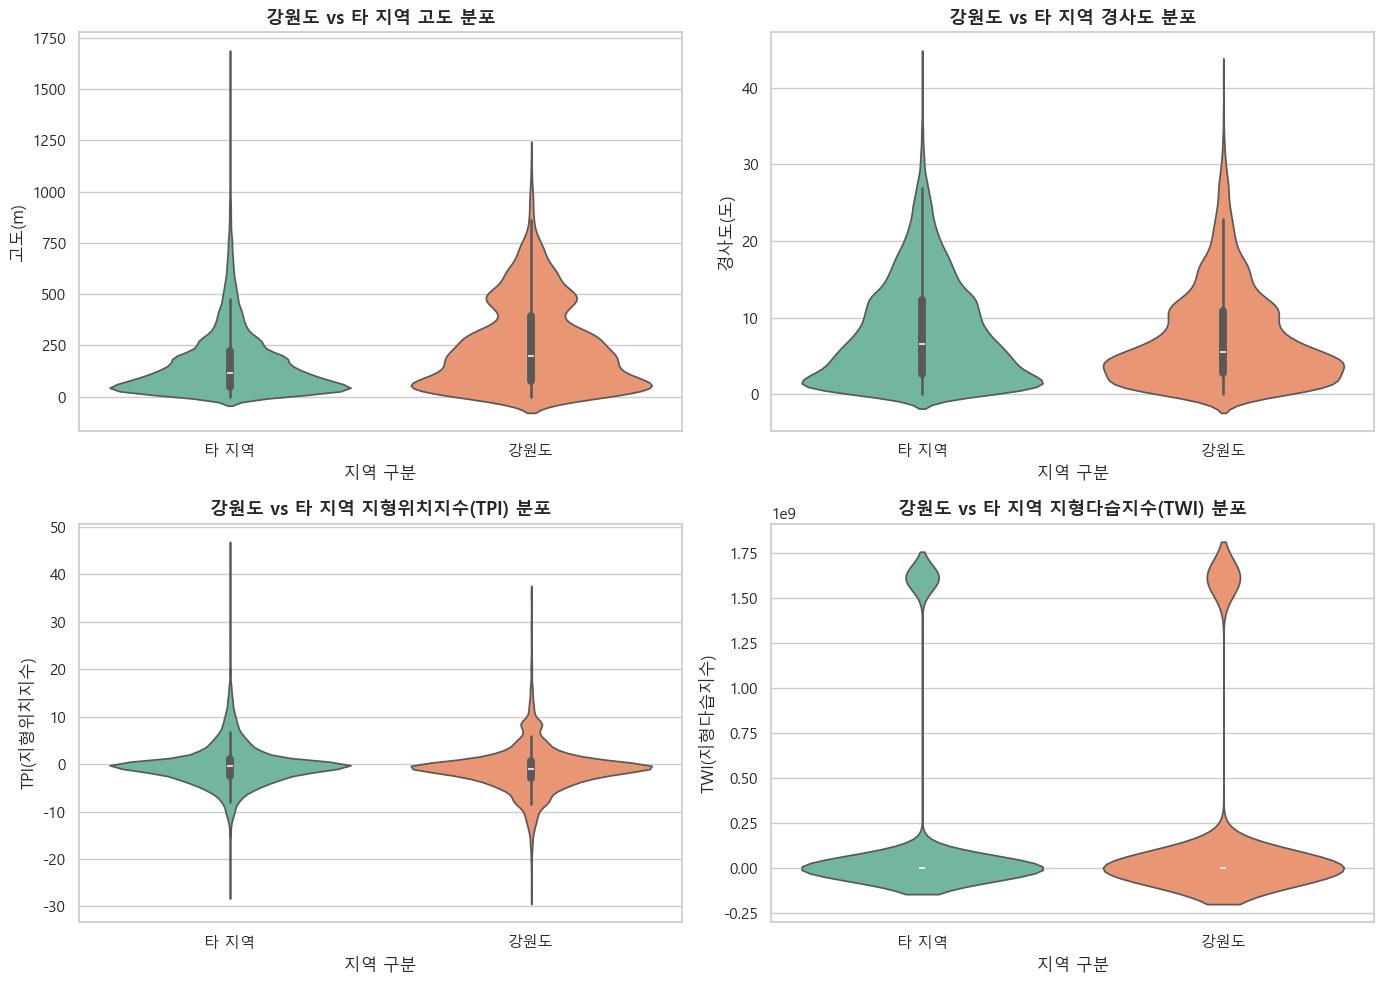

In [9]:
# 지형특성 violin plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
titles = ['고도 분포', '경사도 분포', '지형위치지수(TPI) 분포', '지형다습지수(TWI) 분포']

for ax, var, title in zip(axes.flatten(), topo_vars, titles):
    plot_df = merged_df[['is_gangwon', var]].dropna()
    sns.violinplot(data=plot_df, x='is_gangwon', y=var, hue='is_gangwon', palette='Set2', ax=ax, legend=False)
    ax.set_title(f'강원도 vs 타 지역 {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('지역 구분')
    ax.set_ylabel(var)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['타 지역', '강원도'])

plt.tight_layout()
plt.show()


--- 8방위별 산불 발생 비율(%) ---
is_gangwon   False  True 
aspect_8dir              
북(N)         16.55  15.46
북동(NE)       14.38  14.40
동(E)         13.79  10.99
남동(SE)        8.98   7.47
남(S)          8.05   7.47
남서(SW)        9.24  11.52
서(W)         15.69  19.42
북서(NW)       13.32  13.26


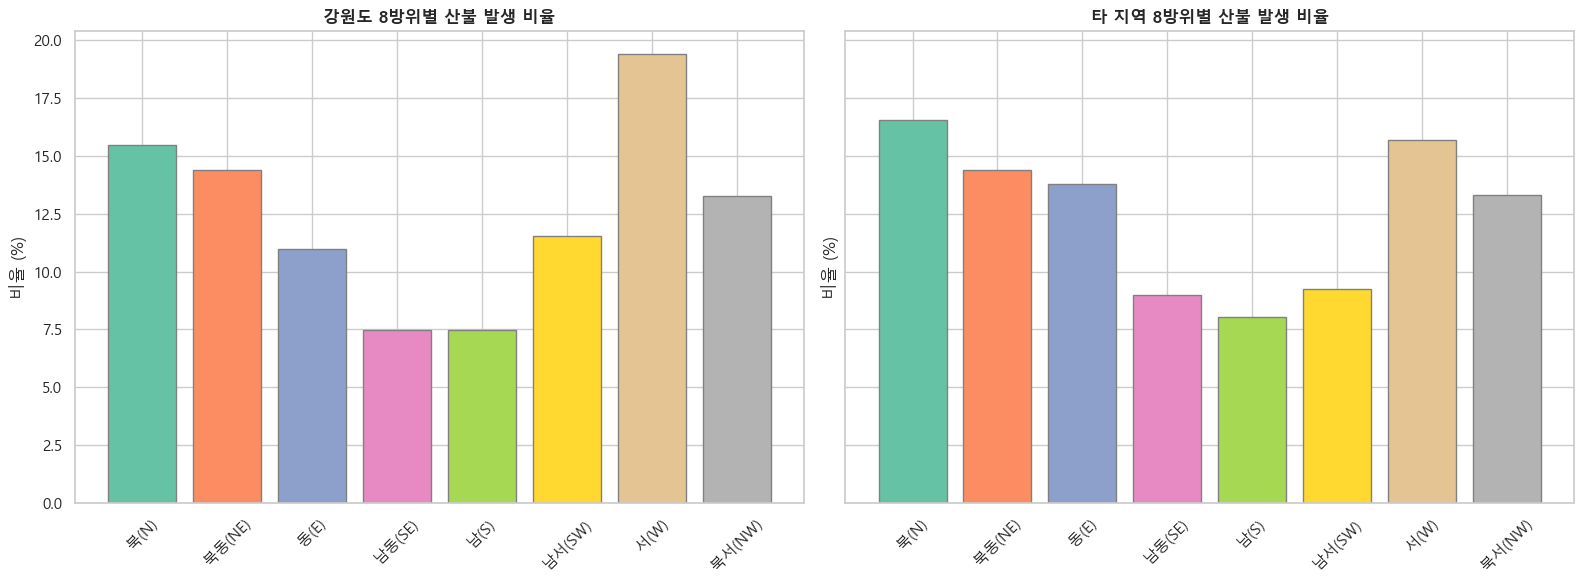

In [10]:
# 사면방향 역변환 및 8방위 분포
if {'사면방향_sin', '사면방향_cos'}.issubset(merged_df.columns):
    merged_df['aspect_deg'] = np.degrees(np.arctan2(merged_df['사면방향_sin'], merged_df['사면방향_cos'])) % 360
    bins = [0, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 360]
    labels = ['북(N)', '북동(NE)', '동(E)', '남동(SE)', '남(S)', '남서(SW)', '서(W)', '북서(NW)', '북(N)']
    merged_df['aspect_8dir'] = pd.cut(merged_df['aspect_deg'], bins=bins, labels=labels, include_lowest=True, ordered=False).astype(str)

    order = ['북(N)', '북동(NE)', '동(E)', '남동(SE)', '남(S)', '남서(SW)', '서(W)', '북서(NW)']
    print('--- 8방위별 산불 발생 비율(%) ---')
    aspect_table = (
        merged_df
        .groupby('is_gangwon')['aspect_8dir']
        .value_counts(normalize=True)
        .mul(100)
        .rename('비율')
        .reset_index()
    )
    print(aspect_table.pivot(index='aspect_8dir', columns='is_gangwon', values='비율').reindex(order).round(2))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    for i, (flag, title) in enumerate([(True, '강원도'), (False, '타 지역')]):
        subset = merged_df[merged_df['is_gangwon'] == flag]
        pcts = subset['aspect_8dir'].value_counts(normalize=True).reindex(order, fill_value=0) * 100
        axes[i].bar(order, pcts.values, color=sns.color_palette('Set2', len(order)), edgecolor='gray')
        axes[i].set_title(f'{title} 8방위별 산불 발생 비율', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('비율 (%)')
        axes[i].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


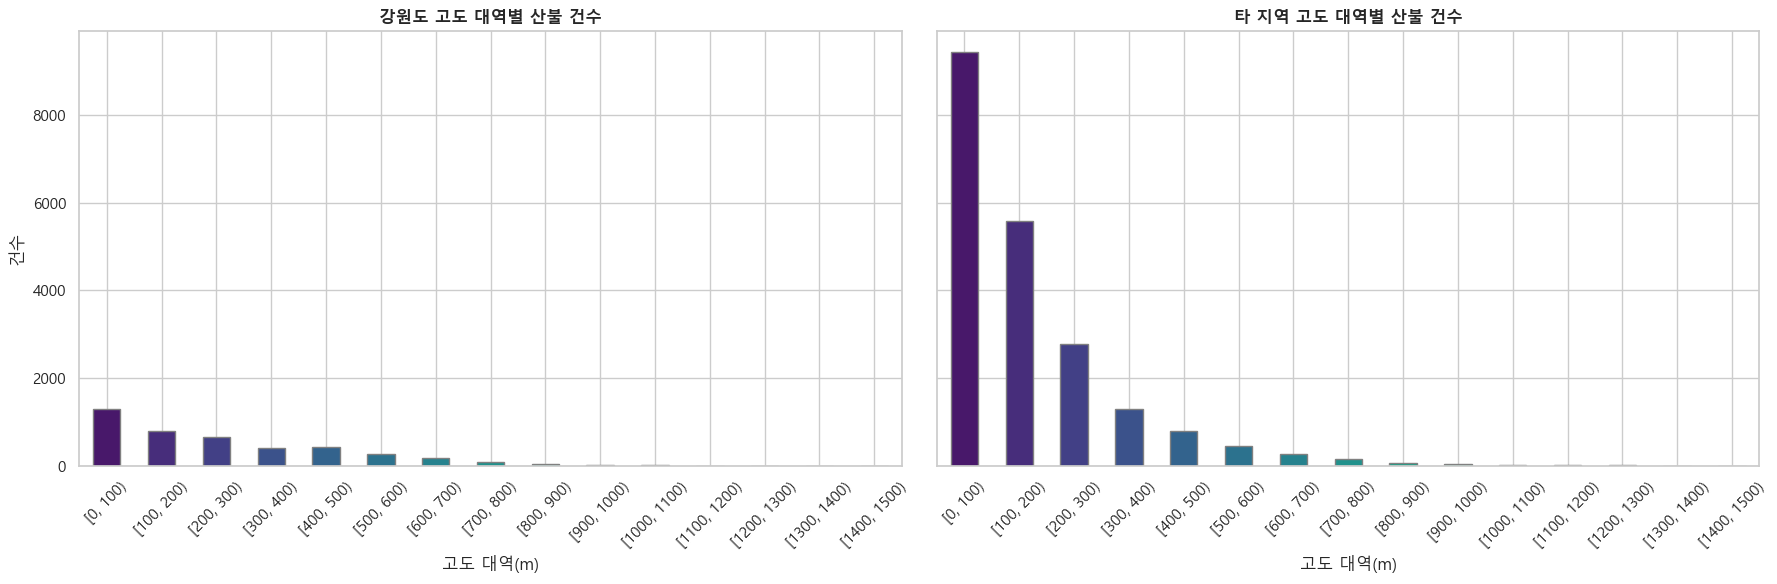

In [11]:
# 고도 대역별 발생 건수
if '고도(m)' in merged_df.columns:
    merged_df['elev_band'] = pd.cut(merged_df['고도(m)'], bins=range(0, 1600, 100), right=False)
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    for i, (flag, title) in enumerate([(True, '강원도'), (False, '타 지역')]):
        subset = merged_df[merged_df['is_gangwon'] == flag]
        band_counts = subset['elev_band'].value_counts().sort_index()
        band_counts.plot(kind='bar', ax=axes[i], color=sns.color_palette('viridis', len(band_counts)), edgecolor='gray')
        axes[i].set_title(f'{title} 고도 대역별 산불 건수', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('고도 대역(m)')
        axes[i].set_ylabel('건수')
        axes[i].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


<!-- spatial-eda-analysis:topography -->
### 4-1. 지형 특성 EDA 결과 및 플롯 이미지 분석

- 고도 violin plot에서 강원도 분포는 타 지역보다 중심이 위로 이동해 있습니다. 강원도 중앙값은 **197.46m**, 타 지역 중앙값은 **114.91m**이며, 강원도는 300~500m 부근의 두꺼운 밀도가 더 뚜렷합니다.
- 경사도는 타 지역이 상단 꼬리와 중앙값 모두 약간 더 큽니다. 강원도 중앙값은 **5.50도**, 타 지역은 **6.57도**라서, 강원도 산불을 단순히 급경사 산악 지형으로만 설명하기는 어렵습니다.
- TPI는 양쪽 모두 0 부근에 밀집하지만 강원도가 음수 방향으로 약간 더 치우쳐 있습니다. 이는 능선보다 사면/곡지성 지형의 비중이 일부 섞여 있을 가능성을 보여주지만, 분포 폭이 넓어 현재 단계에서는 단정하지 않습니다.
- TWI plot은 대부분 값이 낮은 영역에 몰려 있고 매우 큰 이상치 축 때문에 본체 분포가 눌려 보입니다. 평균보다 중앙값과 분위수를 우선해서 봐야 하며, 추가 EDA에서는 로그 변환 또는 극단값 처리 기준을 따로 잡는 것이 필요합니다.
- 사면방향 플롯에서는 강원도 서향(W)이 **19.42%**로 가장 높고 남서향(SW)도 **11.52%**입니다. 타 지역도 서향 비중이 높지만 강원도에서 서향 쏠림이 더 강하게 보이므로, 양간지풍/서풍 계열 기상 분석과 연결할 후보 패턴입니다.
- 고도 대역 막대그래프는 두 지역 모두 저고도대 발생이 많지만, 강원도는 100~500m 구간의 상대적 비중이 더 완만하게 이어지고 타 지역은 0~200m 저고도대에 더 급격히 집중됩니다.

## 5. 예방·소방 시설 접근성 EDA

소방서, 소방용수시설, 산불소화시설, 등산로, 임도까지의 최단거리와 인접 시설 속성을 확인한다. 접근성 자체의 분포와 이상치를 먼저 확인하고, 진화시간과의 관계는 탐색 수준으로만 정리한다.

In [12]:
# 시설물 최단거리 분포 요약
dist_vars = [
    'nearest_station_dist_km', 'nearest_water_dist_km', 'nearest_facility_dist_km',
    'nearest_trail_dist_km', 'nearest_road_dist_km'
]
dist_vars = [c for c in dist_vars if c in merged_df.columns]

records = []
for var in dist_vars:
    for flag, label in [(True, '강원도'), (False, '타 지역')]:
        s = merged_df.loc[merged_df['is_gangwon'] == flag, var].dropna()
        records.append({
            '변수': var,
            '지역': label,
            '유효 N': len(s),
            '평균': s.mean(),
            '중앙값': s.median(),
            'Q1': s.quantile(0.25),
            'Q3': s.quantile(0.75),
            'P95': s.quantile(0.95),
            '최댓값': s.max(),
        })

dist_summary = pd.DataFrame(records)
print(dist_summary.round(4).to_string(index=False))


                      변수   지역  유효 N      평균     중앙값     Q1      Q3     P95      최댓값
 nearest_station_dist_km  강원도  4139  5.7294  4.6445 1.6180  8.5106 15.2059  32.0838
 nearest_station_dist_km 타 지역 20897  7.4375  4.6681 2.0496  8.3386 20.9709 106.5006
   nearest_water_dist_km  강원도  4139  1.1576  0.3802 0.1347  1.5592  4.6391  11.7733
   nearest_water_dist_km 타 지역 20897  2.9683  0.6801 0.2790  1.5049  9.7837  94.9087
nearest_facility_dist_km  강원도  4139 13.1320 12.8530 7.9839 17.7977 23.0253  29.4765
nearest_facility_dist_km 타 지역 20897 14.8863 12.2107 7.1010 19.3470 32.4520 178.4054
   nearest_trail_dist_km  강원도  4139  1.8448  1.1245 0.4470  2.5524  6.4804  17.4402
   nearest_trail_dist_km 타 지역 20897  4.4838  1.5527 0.4060  3.5278 17.1699 143.5195
    nearest_road_dist_km  강원도  4139  4.3610  3.6120 2.3415  6.2445 10.0851  27.0711
    nearest_road_dist_km 타 지역 20897 13.0193  8.7483 4.2633 16.5727 38.2110 198.6110


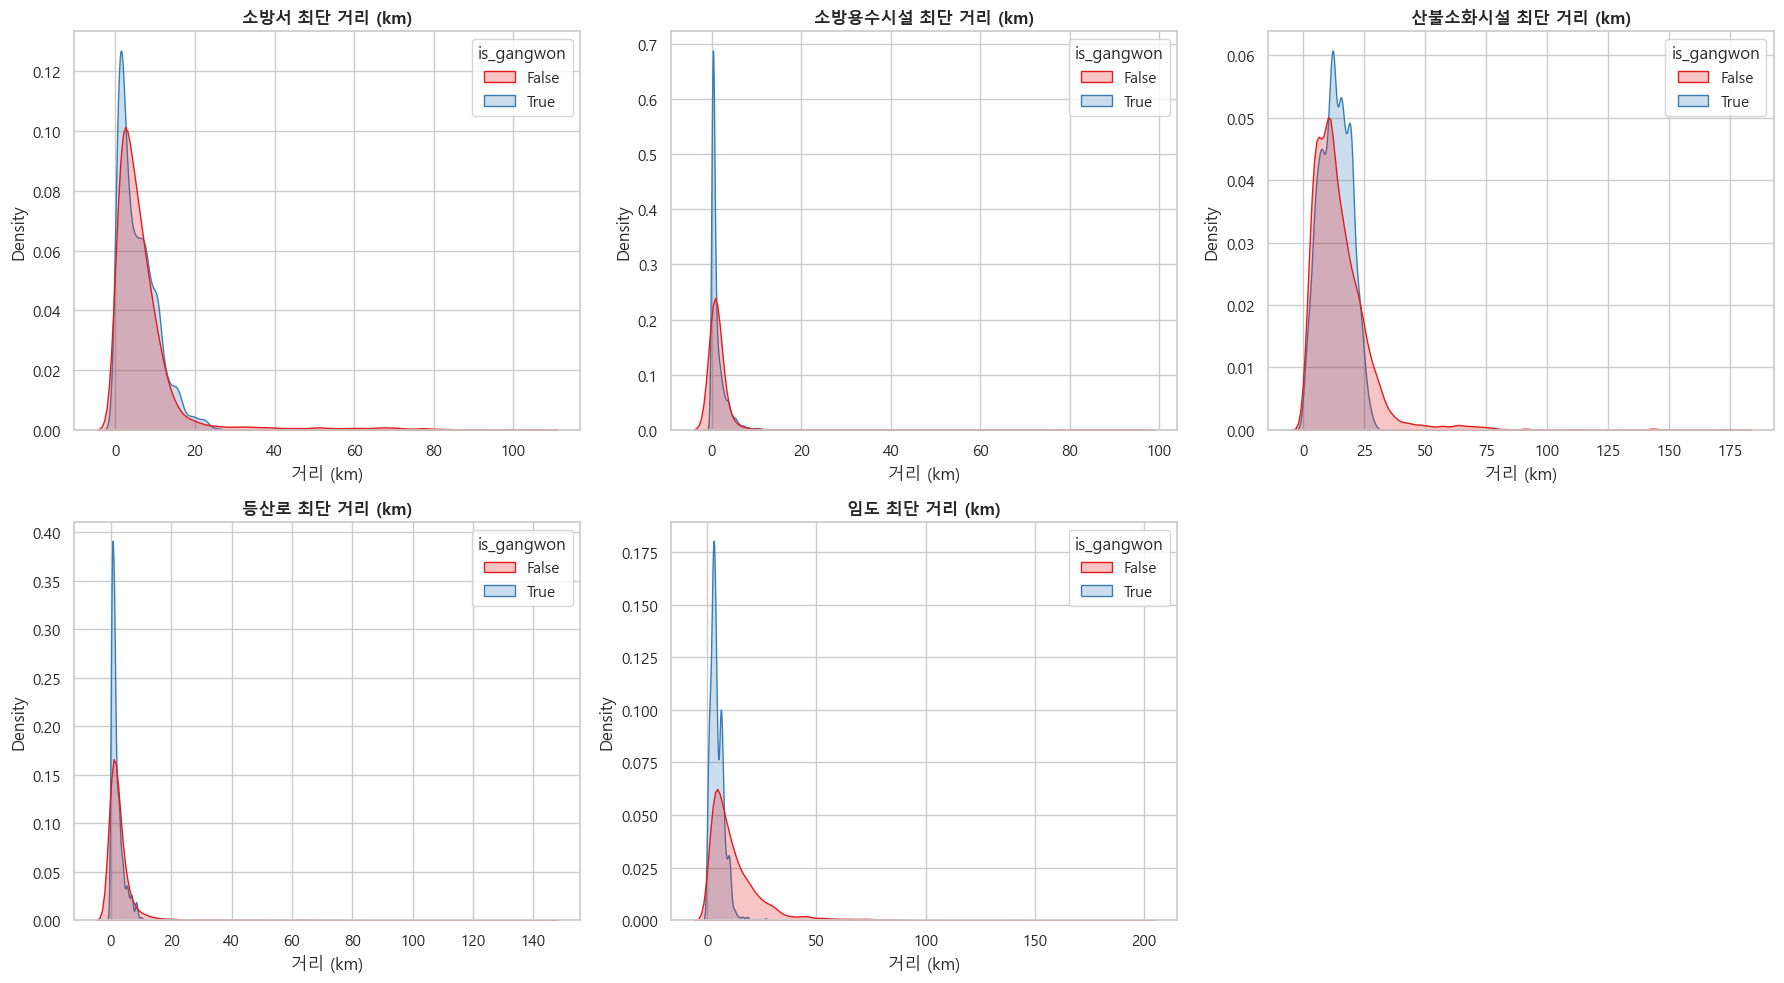

In [13]:
# 시설물 최단거리 KDE
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
dist_titles = {
    'nearest_station_dist_km': '소방서 최단 거리 (km)',
    'nearest_water_dist_km': '소방용수시설 최단 거리 (km)',
    'nearest_facility_dist_km': '산불소화시설 최단 거리 (km)',
    'nearest_trail_dist_km': '등산로 최단 거리 (km)',
    'nearest_road_dist_km': '임도 최단 거리 (km)',
}

for i, var in enumerate(dist_vars):
    ax = axes[i // 3, i % 3]
    plot_df = merged_df[['is_gangwon', var]].dropna()
    sns.kdeplot(data=plot_df, x=var, hue='is_gangwon', fill=True, common_norm=False, palette='Set1', ax=ax)
    ax.set_title(dist_titles.get(var, var), fontsize=12, fontweight='bold')
    ax.set_xlabel('거리 (km)')

for j in range(len(dist_vars), 6):
    fig.delaxes(axes[j // 3, j % 3])

plt.tight_layout()
plt.show()


In [14]:
# 인접 임도/등산로/소화시설 속성 분포
cat_cols = ['nearest_road_width_m', 'nearest_trail_difficulty', 'nearest_trail_material', 'nearest_facility_remote']

for col in cat_cols:
    if col not in merged_df.columns:
        continue
    print('\n' + '=' * 90)
    print(f'[{col}]')
    if pd.api.types.is_numeric_dtype(merged_df[col]):
        print(merged_df.groupby('is_gangwon')[col].describe().round(4))
    else:
        tab = pd.crosstab(merged_df[col], merged_df['is_gangwon'], normalize='columns').mul(100).round(2)
        print(tab.sort_values(True if True in tab.columns else tab.columns[-1], ascending=False).head(15))

if 'nearest_road_width_m' in merged_df.columns:
    merged_df['road_width_band'] = pd.cut(
        merged_df['nearest_road_width_m'],
        bins=[0, 2, 3, 4, 6, 10, np.inf],
        labels=['2m 이하', '2~3m', '3~4m', '4~6m', '6~10m', '10m 초과'],
        right=False,
    )
    print('\n--- 임도 폭 대역별 비율(%) ---')
    print(pd.crosstab(merged_df['road_width_band'], merged_df['is_gangwon'], normalize='columns').mul(100).round(2))



[nearest_road_width_m]
              count    mean     std  min  25%  50%  75%  max
is_gangwon                                                  
False       20897.0  3.6812  0.5854  2.5  3.0  4.0  4.0  6.0
True         4139.0  3.7735  0.4969  2.5  3.5  4.0  4.0  6.0

[nearest_trail_difficulty]
is_gangwon                False  True 
nearest_trail_difficulty              
쉬움                        98.66  98.16
중간                         0.76   1.57
0                          0.53   0.27
상                          0.02   0.00
어려움                        0.04   0.00

[nearest_trail_material]
is_gangwon              False  True 
nearest_trail_material              
0                       87.92  92.53
토사                       6.34   4.37
토사/암반                    1.27   1.26
섞인토사                     0.25   0.85
흙길                       0.33   0.36
토사,암반                    0.01   0.24
자갈/토반                    0.00   0.12
토양,암석                    0.00   0.10
점토질                      0.01   0.0

<!-- spatial-eda-analysis:access -->
### 5-1. 예방·소방 시설 접근성 EDA 결과 및 플롯 이미지 분석

- 거리 KDE 플롯은 강원도(True) 분포가 대부분의 시설 거리에서 더 좁고 왼쪽에 몰려 있음을 보여줍니다. 즉 현재 피처 기준으로는 강원도 산불 지점이 시설·노선에서 일괄적으로 더 멀다고 보기 어렵습니다.
- 수치상 강원도 평균 최단거리는 소방서 **5.73km**, 소방용수 **1.16km**, 산불소화시설 **13.13km**, 등산로 **1.84km**, 임도 **4.36km**입니다. 타 지역 평균은 각각 **7.44km**, **2.97km**, **14.89km**, **4.48km**, **13.02km**입니다.
- 특히 임도와 등산로 거리에서 타 지역은 긴 오른쪽 꼬리가 강하게 나타납니다. 강원도는 임도 P95가 **10.09km**인 반면 타 지역은 **38.21km**까지 늘어나, 접근성 변수는 지역별 지리적 범위 차이와 함께 해석해야 합니다.
- 임도 폭은 양쪽 모두 3~6m에 집중되어 있고, 강원도는 4~6m 구간 비율이 **61.34%**로 타 지역 **55.48%**보다 큽니다. `2~3m` 구간은 매우 작아, 좁은 임도 구간 해석에는 표본 불균형을 먼저 고려해야 합니다.
- 등산로 난이도는 `쉬움`이 양쪽 모두 98% 안팎으로 압도적입니다. 난이도 변수만으로 산불 위험 차이를 설명하기에는 범주 다양성이 부족합니다.
- 산불소화시설 원격제어는 강원도 인근에서 `불가능` 비율이 **80.19%**로 타 지역 **68.54%**보다 높게 보입니다. 단순 거리보다 시설 기능 수준을 별도 피처로 검토할 필요가 있습니다.

## 6. 토지피복 및 산림 수종 EDA

산불 발생지 300m 반경의 대분류 토지피복 비율과 산림 수종 세분류 비율을 확인한다. 지역별 분류 해상도나 원천 데이터 누락 가능성이 있으므로 평균 비율과 유효 표본 수를 함께 본다.

--- 대분류 토지피복 평균 비율 ---
is_gangwon      False   True 
산림지역_ratio     0.4745  0.4427
농업지역_ratio     0.1805  0.1672
초지_ratio       0.0780  0.0224
습지_ratio       0.0083  0.0018
나지_ratio       0.0323  0.0171
수역_ratio       0.0166  0.0059
시가화건조지역_ratio  0.1243  0.1014

--- 대분류 토지피복 유효 표본 수 ---
is_gangwon     False  True 
산림지역_ratio     20897   4139
농업지역_ratio     20897   4139
초지_ratio       20897   4139
습지_ratio       20897   4139
나지_ratio       20897   4139
수역_ratio       20897   4139
시가화건조지역_ratio  20897   4139


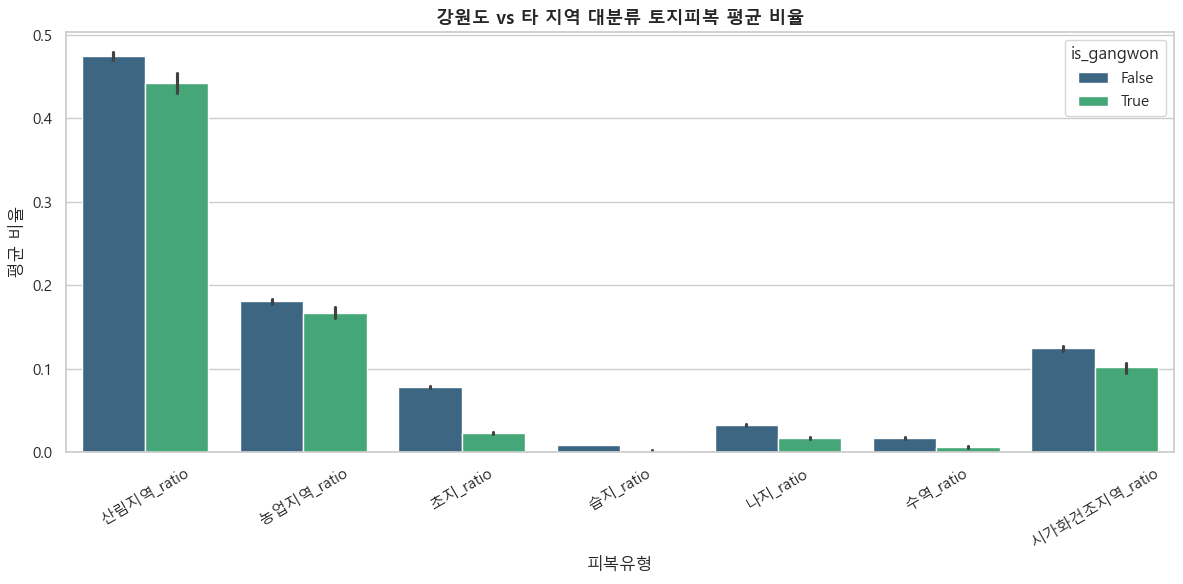

In [15]:
# 대분류 토지피복 비율
major_lc_cols = [c for c in ['산림지역_ratio', '농업지역_ratio', '초지_ratio', '습지_ratio', '나지_ratio', '수역_ratio', '시가화건조지역_ratio'] if c in merged_df.columns]

if major_lc_cols:
    print('--- 대분류 토지피복 평균 비율 ---')
    print(merged_df.groupby('is_gangwon')[major_lc_cols].mean().round(4).T)
    print('\n--- 대분류 토지피복 유효 표본 수 ---')
    print(merged_df.groupby('is_gangwon')[major_lc_cols].count().T)

    lc_melted = merged_df.melt(id_vars=['is_gangwon'], value_vars=major_lc_cols, var_name='피복유형', value_name='비율').dropna()
    plt.figure(figsize=(12, 6))
    sns.barplot(data=lc_melted, x='피복유형', y='비율', hue='is_gangwon', palette='viridis')
    plt.title('강원도 vs 타 지역 대분류 토지피복 평균 비율', fontsize=13, fontweight='bold')
    plt.ylabel('평균 비율')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


--- 산림 수종 세분류 평균 비율 ---
is_gangwon   False   True 
침엽수림_ratio  0.0722  0.0067
활엽수림_ratio  0.0845  0.0072
혼효림_ratio   0.0254  0.0037

--- 산림 수종 세분류 유효 표본 수 ---
is_gangwon  False  True 
침엽수림_ratio  20897   4139
활엽수림_ratio  20897   4139
혼효림_ratio   20897   4139


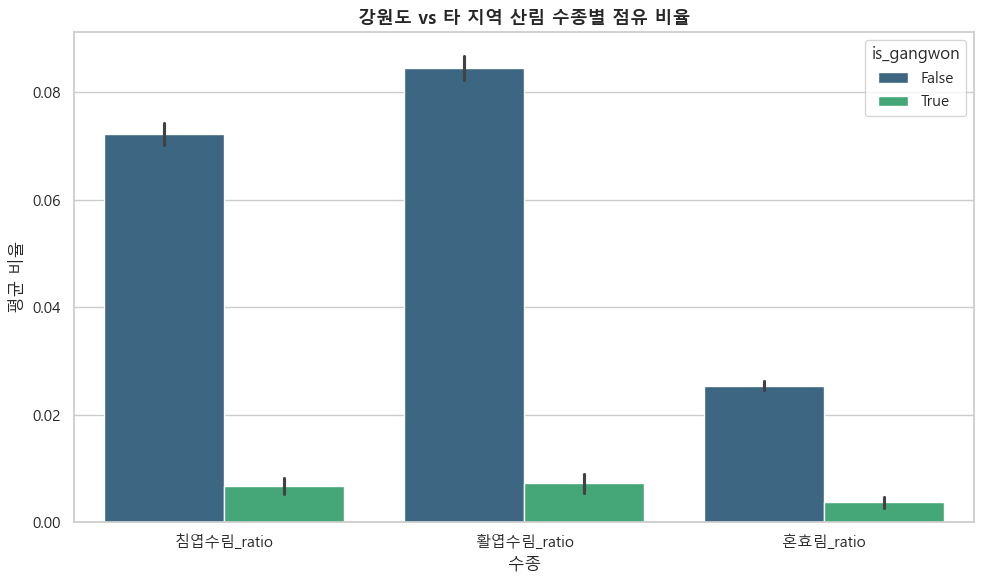

In [16]:
# 산림 수종 세분류 비율
forest_cols = [c for c in ['침엽수림_ratio', '활엽수림_ratio', '혼효림_ratio'] if c in merged_df.columns]

if forest_cols:
    print('--- 산림 수종 세분류 평균 비율 ---')
    print(merged_df.groupby('is_gangwon')[forest_cols].mean().round(4).T)
    print('\n--- 산림 수종 세분류 유효 표본 수 ---')
    print(merged_df.groupby('is_gangwon')[forest_cols].count().T)

    forest_melted = merged_df.melt(id_vars=['is_gangwon'], value_vars=forest_cols, var_name='수종', value_name='비율').dropna()
    plt.figure(figsize=(10, 6))
    sns.barplot(data=forest_melted, x='수종', y='비율', hue='is_gangwon', palette='viridis')
    plt.title('강원도 vs 타 지역 산림 수종별 점유 비율', fontsize=13, fontweight='bold')
    plt.ylabel('평균 비율')
    plt.tight_layout()
    plt.show()


<!-- spatial-eda-analysis:landcover -->
### 6-1. 토지피복 및 산림 수종 EDA 결과와 플롯 이미지 분석

- 대분류 토지피복 plot에서 산림지역 비율은 타 지역 **0.4745**, 강원도 **0.4427**로 강원도가 약간 낮습니다. 농업지역과 시가화건조지역도 강원도가 낮고, 초지·습지·나지·수역 비율은 차이가 더 큽니다.
- 강원도가 산림 산불 지역이라는 직관과 달리 300m 반경 평균 산림지역 비율이 더 높게 나오지는 않습니다. 이는 산불 발생점 주변 버퍼의 토지피복 구성, 행정권역별 데이터 해상도, 산불 위치의 산림 경계부 포함 여부를 함께 확인해야 함을 의미합니다.
- 산림 수종 세분류 plot에서는 강원도 침엽수림 **0.0067**, 활엽수림 **0.0072**, 혼효림 **0.0037**로 타 지역보다 현저히 낮습니다. 이 격차는 실제 수종 차이라기보다 세분류 토지피복 매칭 또는 지역별 분류 해상도 차이 가능성이 커 보입니다.
- 따라서 모델링에서는 대분류 `산림지역_ratio`를 우선 검토하고, 침엽수림/활엽수림/혼효림 비율은 원천 GPKG의 분류 누락 또는 집계 방식 검증 후 보조 피처로 쓰는 편이 안전합니다.

## 7. 진화소요시간과 공간 피처의 탐색적 관계

진화소요시간은 모델링 타깃 또는 사후 결과 변수에 가깝기 때문에, 여기서는 거리 대역·임도 폭 대역별 단순 분포만 확인한다. 여기서는 거리 대역·임도 폭 대역별 단순 분포만 확인한다.

진화소요시간 컬럼: 진화소요시간(HH)
유효 진화소요시간 건수: 6,439
             count    mean     std     min     25%     50%     75%      max
is_gangwon                                                                 
False       5707.0  2.0194  3.3130  0.0500  0.6667  1.1667  2.0000  76.0000
True         732.0  2.7753  5.3735  0.0167  0.8333  1.4167  2.4167  71.6667

--- 소방서 거리 대역별 진화소요시간 탐색 요약 ---
              count    mean  median  대형산불비율(%)
station_band                                  
[0, 2)         1158  1.4135  0.8000     1.7271
[2, 4)         1409  1.9281  1.0333     2.9808
[4, 6)         1215  2.1516  1.1667     3.5391
[6, 8)          927  2.3253  1.3333     3.9914
[8, 10)         696  2.2983  1.3333     4.0230
[10, 15)        752  2.6534  1.5000     5.0532
[15, 20)        186  2.5200  1.5333     4.3011
[20, 50)         88  4.0015  2.2083    10.2273


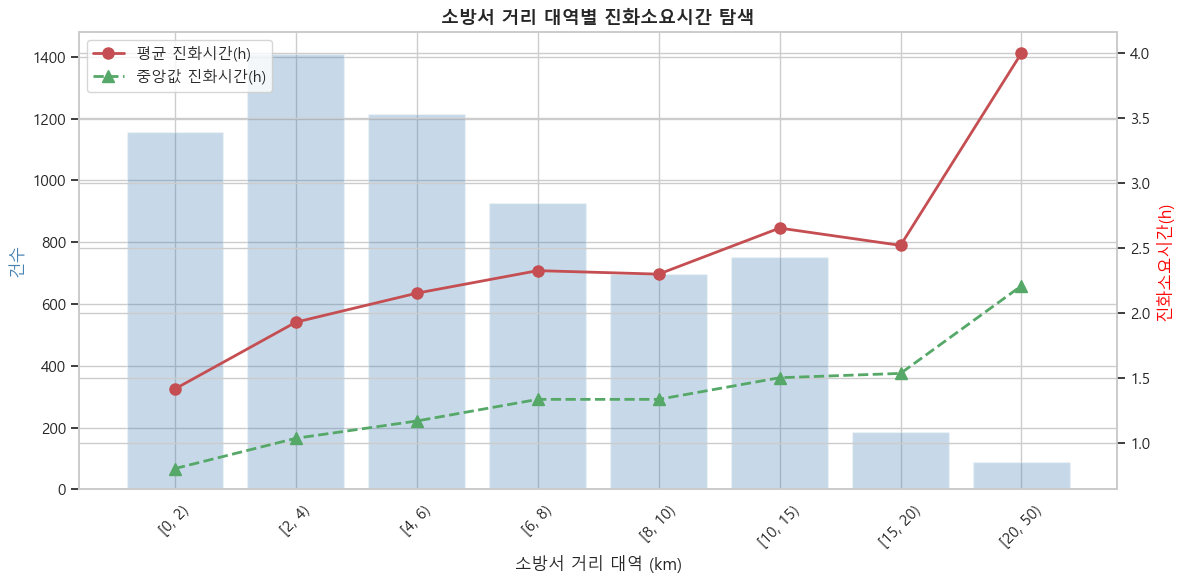

In [17]:
# 진화소요시간 유효 데이터 및 거리 대역별 탐색 요약
suppression_candidates = [c for c in ['진화소요시간(HH)', '진화소요시간'] if c in merged_df.columns]

if suppression_candidates:
    suppression_col = suppression_candidates[0]
    merged_df['_suppression_hours'] = pd.to_numeric(merged_df[suppression_col], errors='coerce')
    valid_sup = merged_df[(merged_df['_suppression_hours'] > 0) & merged_df['_suppression_hours'].notna()].copy()
    print(f'진화소요시간 컬럼: {suppression_col}')
    print(f'유효 진화소요시간 건수: {len(valid_sup):,}')
    print(valid_sup.groupby('is_gangwon')['_suppression_hours'].describe().round(4))

    if 'nearest_station_dist_km' in valid_sup.columns:
        valid_sup['station_band'] = pd.cut(valid_sup['nearest_station_dist_km'], bins=[0, 2, 4, 6, 8, 10, 15, 20, 50], right=False)
        band_stats = valid_sup.groupby('station_band', observed=False)['_suppression_hours'].agg(['count', 'mean', 'median'])
        band_stats['대형산불비율(%)'] = valid_sup.groupby('station_band', observed=False)['_suppression_hours'].apply(lambda s: (s >= 12).mean() * 100)
        print('\n--- 소방서 거리 대역별 진화소요시간 탐색 요약 ---')
        print(band_stats.round(4))

        fig, ax1 = plt.subplots(figsize=(12, 6))
        x = range(len(band_stats))
        ax1.bar(x, band_stats['count'], alpha=0.3, color='steelblue', label='건수')
        ax1.set_ylabel('건수', color='steelblue')
        ax1.set_xlabel('소방서 거리 대역 (km)')
        ax1.set_xticks(x)
        ax1.set_xticklabels([str(b) for b in band_stats.index], rotation=45)

        ax2 = ax1.twinx()
        ax2.plot(x, band_stats['mean'], 'ro-', linewidth=2, markersize=8, label='평균 진화시간(h)')
        ax2.plot(x, band_stats['median'], 'g^--', linewidth=2, markersize=8, label='중앙값 진화시간(h)')
        ax2.set_ylabel('진화소요시간(h)', color='red')
        ax2.legend(loc='upper left')
        plt.title('소방서 거리 대역별 진화소요시간 탐색', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print('진화소요시간 컬럼을 찾지 못했습니다.')


--- 임도 폭 대역별 진화소요시간 탐색 요약 ---
                 count    mean  median
road_width_band                       
2m 이하                0     NaN     NaN
2~3m                17  1.4245  1.3333
3~4m              2822  2.0589  1.1667
4~6m              3599  2.1451  1.1667
6~10m                1  1.5000  1.5000
10m 초과               0     NaN     NaN


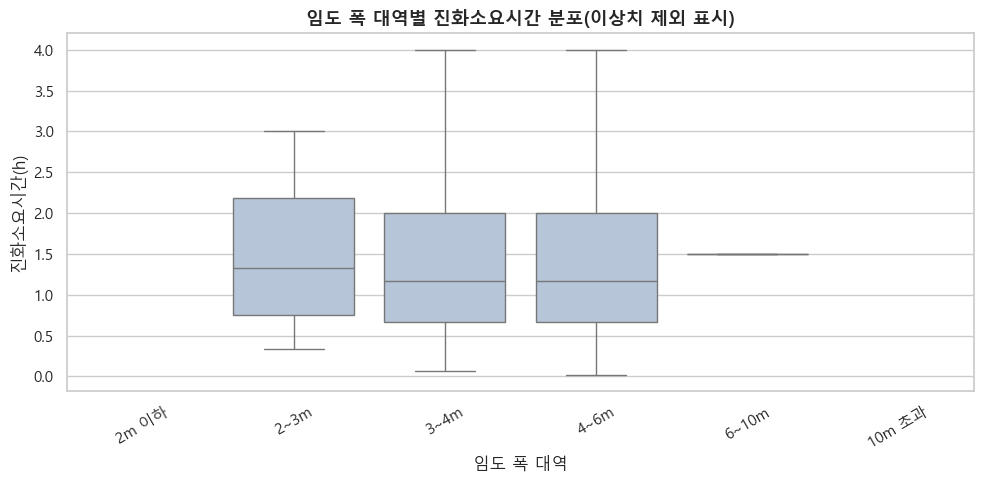

In [18]:
# 임도 폭 대역별 진화소요시간 탐색
if 'valid_sup' in globals() and 'road_width_band' in merged_df.columns:
    valid_sup = valid_sup.merge(
        merged_df[['fire_id', 'road_width_band']],
        on='fire_id',
        how='left',
        suffixes=('', '_from_all')
    ) if 'road_width_band' not in valid_sup.columns and 'fire_id' in valid_sup.columns else valid_sup

    band_col = 'road_width_band' if 'road_width_band' in valid_sup.columns else 'road_width_band_from_all'
    if band_col in valid_sup.columns:
        road_sup = valid_sup.dropna(subset=[band_col, '_suppression_hours'])
        road_stats = road_sup.groupby(band_col, observed=False)['_suppression_hours'].agg(['count', 'mean', 'median']).round(4)
        print('--- 임도 폭 대역별 진화소요시간 탐색 요약 ---')
        print(road_stats)

        plt.figure(figsize=(10, 5))
        sns.boxplot(data=road_sup, x=band_col, y='_suppression_hours', color='lightsteelblue', showfliers=False)
        plt.title('임도 폭 대역별 진화소요시간 분포(이상치 제외 표시)', fontsize=13, fontweight='bold')
        plt.xlabel('임도 폭 대역')
        plt.ylabel('진화소요시간(h)')
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()


<!-- spatial-eda-analysis:suppression -->
### 7-1. 진화소요시간 탐색 결과 및 플롯 이미지 분석

- 진화소요시간 유효 표본은 **6,439건**입니다. 강원도 평균은 **2.78h**, 중앙값은 **1.42h**이고, 타 지역 평균은 **2.02h**, 중앙값은 **1.17h**입니다. 강원도는 평균과 중앙값이 모두 높지만, 이는 아직 기상·피해면적·발생시기 등을 통제하지 않은 탐색 결과입니다.
- 소방서 거리 대역 플롯은 평균 진화시간이 거리 증가와 함께 대체로 올라가는 형태를 보입니다. `[0, 2)km` 평균 **1.41h**에서 `[20, 50)km` 평균 **4.00h**까지 증가하며, 대형산불비율도 **1.73% → 10.23%**로 상승합니다.
- 다만 먼 거리 구간은 표본 수가 급격히 줄어 `[20, 50)km`가 **88건**뿐입니다. 이 구간의 선형 상승을 그대로 일반화하지 말고, 추가 EDA에서는 거리 구간을 병합해 다시 확인하는 편이 좋습니다.
- 임도 폭 boxplot은 3~4m와 4~6m 구간의 중앙값이 거의 비슷합니다. 2~3m는 **17건**, 6~10m는 **1건**이라 시각적으로도 표본 불균형이 뚜렷하며, 좁은 임도 효과는 이 노트북에서 결론 내리지 않는 것이 맞습니다.

## 8. 공간 피처 간 상관관계

주요 수치형 공간 피처 간 상관관계를 확인하여 중복 피처와 모델링 시 다중공선성 가능성을 사전에 파악한다.

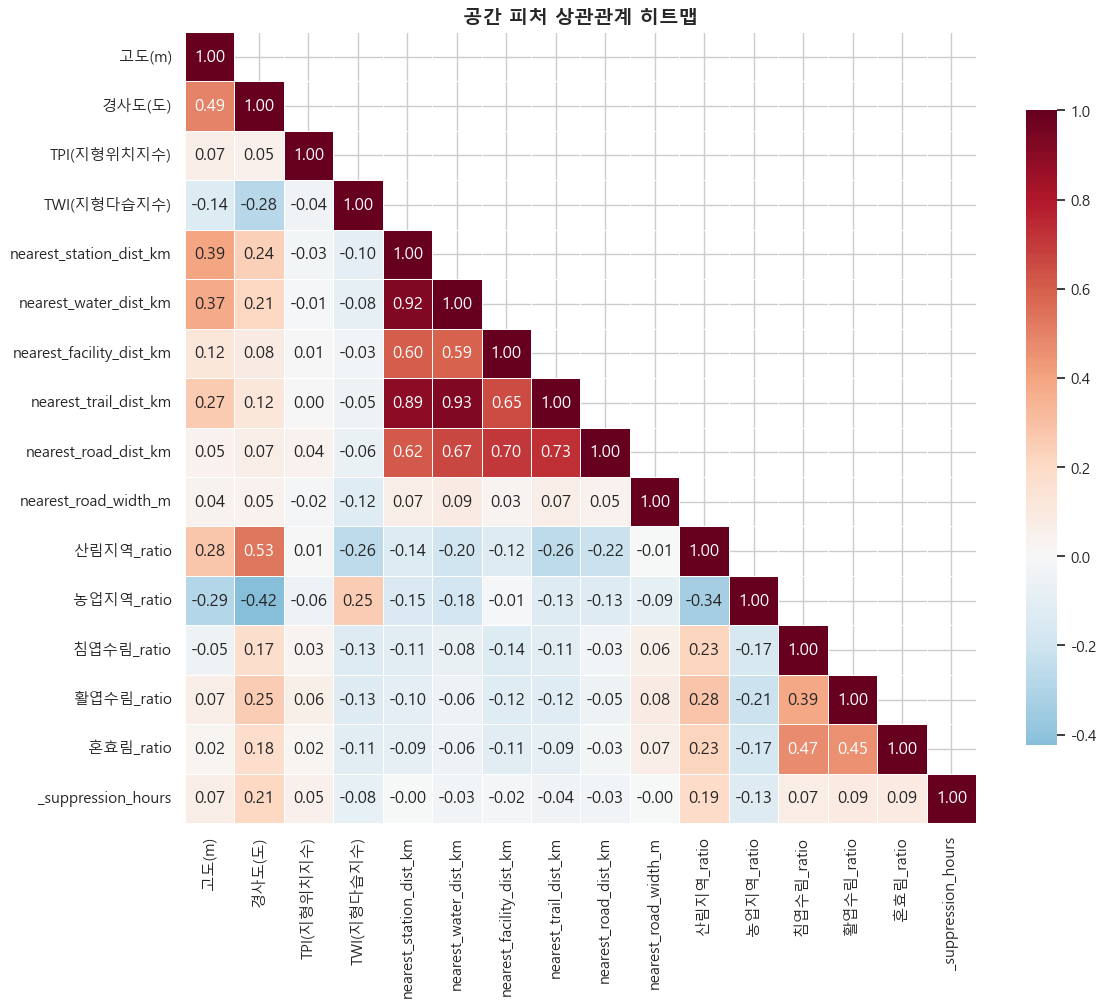

In [19]:
# 공간 피처 상관관계 히트맵
corr_vars = [
    '고도(m)', '경사도(도)', 'TPI(지형위치지수)', 'TWI(지형다습지수)',
    'nearest_station_dist_km', 'nearest_water_dist_km', 'nearest_facility_dist_km',
    'nearest_trail_dist_km', 'nearest_road_dist_km', 'nearest_road_width_m',
    '산림지역_ratio', '농업지역_ratio', '침엽수림_ratio', '활엽수림_ratio', '혼효림_ratio',
]
if '_suppression_hours' in merged_df.columns:
    corr_vars.append('_suppression_hours')

corr_present = [c for c in corr_vars if c in merged_df.columns and pd.api.types.is_numeric_dtype(merged_df[c])]
corr_matrix = merged_df[corr_present].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('공간 피처 상관관계 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


<!-- spatial-eda-analysis:correlation -->
### 8-1. 공간 피처 상관관계 결과 및 플롯 이미지 분석

- 상관관계 히트맵에서 시설 접근성 변수끼리 매우 강한 양의 상관이 보입니다. 소방서-소방용수 거리는 **0.92**, 소방용수-등산로 거리는 **0.93**, 소방서-등산로 거리는 **0.89**입니다.
- 임도 거리도 산불소화시설 거리 **0.70**, 등산로 거리 **0.73**, 소방용수 거리 **0.67**과 같이 접근성 변수군 안에서 함께 움직입니다. 모델링 시 여러 거리 변수를 동시에 넣으면 다중공선성 문제가 생길 수 있습니다.
- 지형에서는 고도와 경사도 상관이 **0.49**로 중간 수준이며, 산림지역 비율은 경사도와 **0.53**의 양의 상관을 보입니다. 산림 비율이 높은 곳이 더 경사진 지형과 겹치는 구조가 있습니다.
- 진화소요시간(`_suppression_hours`)과 개별 공간 피처의 단순 상관은 전반적으로 약합니다. 경사도 **0.21**, 산림지역 비율 **0.19** 정도가 상대적으로 크고, 시설 거리 변수와의 단순 상관은 거의 0에 가깝습니다. 진화시간 설명에는 기상·피해면적·발생시기 같은 비공간 변수를 결합해야 할 가능성이 큽니다.

## 9. 공간 EDA 종합 정리

이번 전국 공간 데이터 EDA는 모델링 전 공간 변수의 구조와 시각적 패턴을 정리하는 단계로 마무리한다.

### 공간 EDA 목록

1. **원천 공간 데이터 구조 확인**: 산불 위치, 지형, 등산로, 산불소화시설, 소방서, 소방용수시설, 임도망도, 토지피복도 파일 구조와 좌표 컬럼을 확인했다.
2. **공간 피처 캐시 로드 및 프로파일링**: `fire_spatial_features.csv` 기준 25,036건 × 60개 피처를 로드했고, 강원도 4,139건과 타 지역 20,897건을 구분했다.
3. **지형 특성 EDA**: 강원도는 타 지역보다 고도 중심이 높지만, 경사도는 타 지역이 약간 더 높았다. TWI는 극단값 영향이 커서 분위수 중심 해석이 필요하다.
4. **사면방향 및 고도 대역 EDA**: 강원도는 서향(W) 비율이 19.42%로 가장 높고, 100~500m 고도 구간이 완만하게 이어지는 패턴을 보였다.
5. **예방·소방 시설 최단거리 EDA**: 강원도는 소방서, 소방용수, 등산로, 임도까지의 평균 최단거리가 타 지역보다 짧았다.
6. **임도·등산로·소화시설 속성 EDA**: 임도 폭은 3~6m에 집중되어 있고, 등산로 난이도는 대부분 `쉬움`으로 치우쳐 있다. 산불소화시설 원격제어 불가능 비율은 강원도가 더 높다.
7. **토지피복 대분류 EDA**: 300m 반경 평균 산림지역 비율은 강원도 0.4427, 타 지역 0.4745로 강원도가 약간 낮았다.
8. **산림 수종 세분류 EDA**: 강원도 수종 세분류 비율이 세 수종 모두 매우 낮아, 원천 토지피복 분류 상태를 먼저 확인해야 한다.
9. **진화소요시간 탐색 EDA**: 강원도 진화소요시간 평균과 중앙값이 타 지역보다 높고, 소방서 거리 대역이 멀어질수록 평균 진화시간이 증가하는 형태가 보였다.
10. **공간 피처 상관관계 EDA**: 시설 접근성 변수끼리 강한 상관이 있으며, 진화소요시간과 개별 공간 피처의 단순 상관은 전반적으로 약했다.

### 캐시 파일 메모

`fire_spatial_features.csv`는 원천 데이터가 아니라 공간 피처 계산 결과 캐시다. 삭제해도 다시 만들 수 있지만, 대용량 공간 연산을 다시 수행해야 하므로 현재 EDA 반복 실행 단계에서는 유지한다.

<!-- spatial-deep-eda:start -->
## 10. 심화 EDA: 공간 피처 복합화 방향

기초 EDA에서는 강원도 산불이 타 지역보다 소방서·소방용수·임도·등산로에 더 가까운 편임에도 평균 진화시간이 길고, 공간 피처 단독 상관은 전반적으로 약하다는 점이 확인되었다.
따라서 이후 분석은 단일 거리 변수보다 다음 세 가지를 중심으로 진행한다.

- 시설·도로 거리들을 결합한 **복합 접근성 지수**를 만들고, 같은 접근성 등급 안에서도 강원도와 타 지역의 진화 결과가 다른지 확인한다.
- 고도, 경사, 산림비율, 접근성, 소화시설 원격제어, 서·남서 사면을 합친 **복합 공간 위험 점수**를 만들어 다중 조건 결합 효과를 본다.
- 시도 단위 공간 프로파일과 변수 상·하위 25% 임계 비교로, 강원도의 위치가 전국 공간 구조 안에서 어떤 의미인지 확인한다.


In [ ]:
# 심화 공간 지표 생성
from scipy import stats

def region_label(flag):
    return '강원도' if bool(flag) else '타 지역'

if {'사면방향_sin', '사면방향_cos'}.issubset(merged_df.columns):
    merged_df['aspect_deg'] = np.degrees(np.arctan2(merged_df['사면방향_sin'], merged_df['사면방향_cos'])) % 360
    aspect_bins = [0, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 360]
    aspect_labels = ['북(N)', '북동(NE)', '동(E)', '남동(SE)', '남(S)', '남서(SW)', '서(W)', '북서(NW)', '북(N)']
    merged_df['aspect_8dir'] = pd.cut(
        merged_df['aspect_deg'],
        bins=aspect_bins,
        labels=aspect_labels,
        include_lowest=True,
        ordered=False
    ).astype(str)

suppression_col = '진화소요시간(HH)' if '진화소요시간(HH)' in merged_df.columns else '진화소요시간'
merged_df['_suppression_hours'] = pd.to_numeric(merged_df[suppression_col], errors='coerce')
merged_df['_suppression_valid'] = (merged_df['_suppression_hours'] > 0) & merged_df['_suppression_hours'].notna()
merged_df['_large_fire_12h'] = np.where(
    merged_df['_suppression_valid'],
    merged_df['_suppression_hours'] >= 12,
    np.nan
)

merged_df['_damage_ha'] = pd.to_numeric(merged_df.get('피해면적(ha)', np.nan), errors='coerce')
merged_df['_log_damage_ha'] = np.log1p(merged_df['_damage_ha'].clip(lower=0))
merged_df['_large_damage_10ha'] = np.where(merged_df['_damage_ha'].notna(), merged_df['_damage_ha'] >= 10, np.nan)

dist_vars = [
    'nearest_station_dist_km',
    'nearest_water_dist_km',
    'nearest_facility_dist_km',
    'nearest_trail_dist_km',
    'nearest_road_dist_km'
]
dist_vars = [c for c in dist_vars if c in merged_df.columns]
for col in dist_vars:
    merged_df[f'{col}_pct'] = merged_df[col].rank(pct=True)

merged_df['access_burden_index'] = merged_df[[f'{c}_pct' for c in dist_vars]].mean(axis=1)
merged_df['access_grade'] = pd.qcut(
    merged_df['access_burden_index'],
    q=[0, 1/3, 2/3, 1],
    labels=['접근 우수', '접근 보통', '접근 취약'],
    duplicates='drop'
)

thresholds = {
    '고고도': ('고도(m)', merged_df['고도(m)'].quantile(0.75)),
    '급경사': ('경사도(도)', merged_df['경사도(도)'].quantile(0.75)),
    '고산림비율': ('산림지역_ratio', merged_df['산림지역_ratio'].quantile(0.75)),
    '접근취약': ('access_burden_index', merged_df['access_burden_index'].quantile(0.75)),
}

merged_df['high_altitude'] = merged_df['고도(m)'] >= thresholds['고고도'][1]
merged_df['high_slope'] = merged_df['경사도(도)'] >= thresholds['급경사'][1]
merged_df['high_forest_ratio'] = merged_df['산림지역_ratio'] >= thresholds['고산림비율'][1]
merged_df['poor_access'] = merged_df['access_burden_index'] >= thresholds['접근취약'][1]
merged_df['remote_unavailable'] = merged_df['nearest_facility_remote'].astype(str).eq('불가능')
merged_df['west_southwest_aspect'] = merged_df.get('aspect_8dir', pd.Series('', index=merged_df.index)).isin(['서(W)', '남서(SW)'])

score_flags = [
    'high_altitude',
    'high_slope',
    'high_forest_ratio',
    'poor_access',
    'remote_unavailable',
    'west_southwest_aspect',
]
merged_df['compound_spatial_score'] = merged_df[score_flags].sum(axis=1)
merged_df['compound_score_band'] = pd.cut(
    merged_df['compound_spatial_score'],
    bins=[-0.1, 1, 2, 3, 6],
    labels=['0-1개', '2개', '3개', '4개 이상']
)

print('심화 공간 지표 생성 완료')
print(f'진화소요시간 유효 표본: {merged_df["_suppression_valid"].sum():,} / {len(merged_df):,}')
print('\n--- 복합 점수 기준 임계값 ---')
for label, (col, value) in thresholds.items():
    print(f'{label}: {col} >= {value:.4f}')
print('\n--- 복합 점수 구성 플래그별 비율(%) ---')
flag_rate = merged_df.groupby('is_gangwon')[score_flags].mean().mul(100).T
flag_rate.columns = ['타 지역', '강원도']
print(flag_rate.round(2).to_string())


## 11. 복합 접근성 지수와 진화 결과

소방서, 소방용수, 산불소화시설, 등산로, 임도 최단거리의 분위 순위를 평균해 `access_burden_index`를 만들었다.
값이 높을수록 여러 접근성 변수에서 동시에 멀다는 뜻이며, 전체 표본을 3분위로 나눠 `접근 우수`, `접근 보통`, `접근 취약`으로 구분했다.


In [ ]:
# 접근성 등급별 진화 결과 요약 및 시각화
access_rows = []
for (flag, grade), g in merged_df.groupby(['is_gangwon', 'access_grade'], observed=True):
    valid = g[g['_suppression_valid']]
    access_rows.append({
        '지역': region_label(flag),
        '접근성 등급': str(grade),
        '전체 N': len(g),
        '진화시간 유효 N': len(valid),
        '접근부담지수 평균': g['access_burden_index'].mean(),
        '평균 진화시간(h)': valid['_suppression_hours'].mean(),
        '중앙 진화시간(h)': valid['_suppression_hours'].median(),
        '12h 이상 비율(%)': valid['_large_fire_12h'].mean() * 100,
        '평균 피해면적(ha)': g['_damage_ha'].mean(),
        '10ha 이상 피해 비율(%)': g['_large_damage_10ha'].mean() * 100,
    })

access_summary = pd.DataFrame(access_rows)
print(access_summary.round(4).to_string(index=False))

region_order = ['타 지역', '강원도']
grade_order = ['접근 우수', '접근 보통', '접근 취약']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=access_summary,
    x='접근성 등급',
    y='평균 진화시간(h)',
    hue='지역',
    order=grade_order,
    hue_order=region_order,
    palette=['#4C78A8', '#F58518'],
    ax=axes[0]
)
axes[0].set_title('접근성 등급별 평균 진화시간', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('평균 진화시간(h)')

sns.barplot(
    data=access_summary,
    x='접근성 등급',
    y='12h 이상 비율(%)',
    hue='지역',
    order=grade_order,
    hue_order=region_order,
    palette=['#4C78A8', '#F58518'],
    ax=axes[1]
)
axes[1].set_title('접근성 등급별 대형 산불(12h+) 비율', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('비율(%)')
plt.tight_layout()
plt.show()


<!-- spatial-deep-eda-analysis:access -->

**결과 및 플롯 이미지 분석**

- 접근성 등급이 `접근 우수 → 접근 취약`으로 갈수록 평균 진화시간과 12시간 이상 대형 산불 비율이 함께 상승한다. 시설·도로 접근성이 나쁠수록 진화 부담이 커지는 기본 방향성은 타당하다.
- 그러나 같은 접근성 등급 안에서도 강원도 막대가 모든 구간에서 타 지역보다 높다. 예를 들어 `접근 우수`에서도 강원도 평균 진화시간은 **2.21h**, 12h 이상 비율은 **4.98%**로 타 지역의 **1.61h**, **2.23%**보다 높다.
- `접근 취약` 구간에서도 강원도는 **3.32h**, **6.53%**로 타 지역의 **2.27h**, **3.68%**를 상회한다. 즉 강원도 산불의 진화 지연은 단순히 소방서·임도·용수시설까지의 물리적 거리가 멀어서 생긴 현상으로 보기 어렵다.
- 이 결과는 앞선 기상 EDA의 결론과 연결된다. 공간 접근성이 상대적으로 양호한 사건에서도 강원도는 고풍속·저습·지형성 바람 조건 때문에 진화 난도가 추가로 상승하는 구조로 해석하는 편이 자연스럽다.


## 12. 지형·피복·시설 복합 공간 위험 점수

전국 상위 25% 임계값을 기준으로 고고도, 급경사, 높은 산림비율, 접근 취약을 플래그화했다.
여기에 산불소화시설 원격제어 불가능 여부와 서·남서 사면 여부를 더해 0~6점의 `compound_spatial_score`를 만들었다.
점수는 인과 모델이 아니라, 공간 조건이 한 사건에 얼마나 많이 겹쳤는지 보는 탐색용 지표이다.


In [ ]:
# 복합 공간 위험 점수별 결과 요약 및 시각화
score_rows = []
for (flag, band), g in merged_df.groupby(['is_gangwon', 'compound_score_band'], observed=True):
    valid = g[g['_suppression_valid']]
    region_n = max((merged_df['is_gangwon'] == flag).sum(), 1)
    score_rows.append({
        '지역': region_label(flag),
        '복합점수': str(band),
        '전체 N': len(g),
        '지역 내 비율(%)': len(g) / region_n * 100,
        '진화시간 유효 N': len(valid),
        '평균 진화시간(h)': valid['_suppression_hours'].mean(),
        '중앙 진화시간(h)': valid['_suppression_hours'].median(),
        '12h 이상 비율(%)': valid['_large_fire_12h'].mean() * 100,
        '평균 피해면적(ha)': g['_damage_ha'].mean(),
        '10ha 이상 피해 비율(%)': g['_large_damage_10ha'].mean() * 100,
    })

score_summary = pd.DataFrame(score_rows)
print(score_summary.round(4).to_string(index=False))

score_order = ['0-1개', '2개', '3개', '4개 이상']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=score_summary,
    x='복합점수',
    y='지역 내 비율(%)',
    hue='지역',
    order=score_order,
    hue_order=region_order,
    palette=['#59A14F', '#E45756'],
    ax=axes[0]
)
axes[0].set_title('복합 공간 위험 점수 분포', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('지역 내 비율(%)')

sns.barplot(
    data=score_summary,
    x='복합점수',
    y='12h 이상 비율(%)',
    hue='지역',
    order=score_order,
    hue_order=region_order,
    palette=['#59A14F', '#E45756'],
    ax=axes[1]
)
axes[1].set_title('복합 공간 위험 점수별 대형 산불 비율', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('12h 이상 비율(%)')
plt.tight_layout()
plt.show()


<!-- spatial-deep-eda-analysis:compound -->

**결과 및 플롯 이미지 분석**

- 강원도는 `0-1개` 저위험 공간 조건의 비율이 **32.86%**로 타 지역 **41.83%**보다 낮고, `2개` 조건이 겹친 사건 비율은 **37.84%**로 타 지역 **29.31%**보다 높다. 강원도 산불은 최소한 2개 이상의 공간 취약 조건을 동반하는 비중이 더 크다.
- 대형 산불 비율은 타 지역에서 복합점수가 높아질수록 완만히 증가한다. 반면 강원도는 `3개` 조건 구간에서 **12h 이상 비율 10.00%**로 뚜렷하게 튄다.
- 다만 강원도의 `4개 이상` 구간은 **4.64%**로 다시 낮아져, 점수가 단순히 높을수록 위험이 항상 증가한다고 해석하면 안 된다. 플롯상 강원도 위험은 선형 누적보다 특정 조합, 특히 고도·사면·시설 기능·접근성 중 일부가 맞물리는 구간에서 급격히 커지는 형태에 가깝다.
- 따라서 이 점수는 최종 모델의 단일 위험 점수로 바로 쓰기보다, 상호작용 후보를 찾는 탐색 피처로 사용하는 것이 적절하다.


## 13. 시도 단위 공간 프로파일과 변수 임계 효과

마지막으로 시도별 중앙 고도와 접근부담 평균의 위치를 비교하고, 주요 공간 변수의 상위 25%와 하위 25%를 나누어 진화 결과 차이를 확인한다.
시도별 프로파일은 강원도가 전국 공간 구조 안에서 어떤 위치에 있는지 보는 용도이며, 임계 비교는 어떤 공간 변수가 결과와 가장 강하게 연결되는지 우선순위를 보는 용도이다.


In [ ]:
# 시도별 공간 취약 프로파일
province_rows = []
for province, g in merged_df.groupby('발생지역시도명'):
    valid = g[g['_suppression_valid']]
    province_rows.append({
        '시도': province,
        'N': len(g),
        '고도 중앙값': g['고도(m)'].median(),
        '접근부담 평균': g['access_burden_index'].mean(),
        '산림비율 중앙값': g['산림지역_ratio'].median(),
        '서/남서 사면 비율(%)': g['west_southwest_aspect'].mean() * 100,
        '진화 유효 N': len(valid),
        '중앙 진화시간(h)': valid['_suppression_hours'].median(),
        '12h 이상 비율(%)': valid['_large_fire_12h'].mean() * 100,
        '피해면적 중앙값(ha)': g['_damage_ha'].median(),
        '10ha 이상 피해 비율(%)': g['_large_damage_10ha'].mean() * 100,
    })

province_profile = pd.DataFrame(province_rows)
print(province_profile.sort_values('12h 이상 비율(%)', ascending=False).round(4).to_string(index=False))

province_plot = province_profile.copy()
province_plot['강원여부'] = province_plot['시도'].isin(['강원도', '강원특별자치도'])

fig, ax = plt.subplots(figsize=(12, 8))
sizes = np.sqrt(province_plot['N']) * 10
colors = province_plot['12h 이상 비율(%)']
scatter = ax.scatter(
    province_plot['고도 중앙값'],
    province_plot['접근부담 평균'],
    s=sizes,
    c=colors,
    cmap='YlOrRd',
    alpha=0.82,
    edgecolor='gray'
)
for _, row in province_plot.iterrows():
    weight = 'bold' if row['강원여부'] else 'normal'
    ax.annotate(
        row['시도'],
        (row['고도 중앙값'], row['접근부담 평균']),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=9,
        fontweight=weight
    )
ax.set_title('시도별 고도-접근부담 공간 프로파일', fontsize=14, fontweight='bold')
ax.set_xlabel('고도 중앙값(m)')
ax.set_ylabel('접근부담지수 평균(높을수록 시설·도로 접근 취약)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('12h 이상 진화 비율(%)')
plt.tight_layout()
plt.show()


In [ ]:
# 공간 변수 상·하위 25% 임계 비교
threshold_features = [
    '고도(m)',
    '경사도(도)',
    '산림지역_ratio',
    'access_burden_index',
    'nearest_station_dist_km',
    'nearest_road_dist_km',
    'nearest_water_dist_km',
]
threshold_rows = []
valid_sup_all = merged_df[merged_df['_suppression_valid']].copy()

for var in [c for c in threshold_features if c in merged_df.columns]:
    q25, q75 = merged_df[var].quantile([0.25, 0.75])
    low = merged_df[merged_df[var] <= q25]
    high = merged_df[merged_df[var] >= q75]
    low_sup = low[low['_suppression_valid']]
    high_sup = high[high['_suppression_valid']]

    rho_sup, p_sup = np.nan, np.nan
    if valid_sup_all[var].notna().sum() > 20:
        rho_sup, p_sup = stats.spearmanr(valid_sup_all[var], valid_sup_all['_suppression_hours'], nan_policy='omit')

    rho_dmg, p_dmg = np.nan, np.nan
    dmg_valid = merged_df[[var, '_damage_ha']].dropna()
    if len(dmg_valid) > 20:
        rho_dmg, p_dmg = stats.spearmanr(dmg_valid[var], dmg_valid['_damage_ha'], nan_policy='omit')

    threshold_rows.append({
        '변수': var,
        '하위25 기준': q25,
        '상위25 기준': q75,
        '하위25 평균 진화(h)': low_sup['_suppression_hours'].mean(),
        '상위25 평균 진화(h)': high_sup['_suppression_hours'].mean(),
        '진화시간 차이(h)': high_sup['_suppression_hours'].mean() - low_sup['_suppression_hours'].mean(),
        '하위25 12h+ 비율(%)': low_sup['_large_fire_12h'].mean() * 100,
        '상위25 12h+ 비율(%)': high_sup['_large_fire_12h'].mean() * 100,
        '12h+ 비율 차이(%p)': high_sup['_large_fire_12h'].mean() * 100 - low_sup['_large_fire_12h'].mean() * 100,
        '피해면적 Spearman': rho_dmg,
        '진화시간 Spearman': rho_sup,
    })

threshold_summary = pd.DataFrame(threshold_rows)
print(threshold_summary.round(4).to_string(index=False))

heat = threshold_summary.set_index('변수')[
    ['진화시간 차이(h)', '12h+ 비율 차이(%p)', '피해면적 Spearman', '진화시간 Spearman']
]
plt.figure(figsize=(11, 6))
sns.heatmap(heat, annot=True, fmt='.3f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('공간 변수 상위25% - 하위25% 결과 차이 및 순위상관', fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()


<!-- spatial-deep-eda-analysis:province-threshold -->

**결과 및 플롯 이미지 분석**

- 시도별 산점도에서 강원특별자치도는 **고도 중앙값 197.46m**로 전국 상위권이지만, 접근부담 평균은 **0.4323**으로 경북·경기·전남·충북보다 낮다. 즉 강원도는 접근성이 전국 최악이라기보다, 상대적으로 접근 가능한 위치에서도 대형 산불 비율이 높게 나타나는 쪽에 가깝다.
- 12h 이상 진화 비율은 강원도가 **5.87%**로 제주특별자치도 다음으로 높지만, 제주는 전체 63건·진화 유효 13건의 소표본이라 안정적 비교군으로 보기 어렵다. 표본 규모를 함께 고려하면 강원도는 전국에서 가장 중요한 대형 산불 고위험 공간 클러스터다.
- 상·하위 25% 임계 비교에서는 `nearest_station_dist_km` 상위 25%가 하위 25%보다 평균 진화시간이 **+1.27h**, 12h 이상 비율이 **+3.37%p** 높아 가장 뚜렷했다. `nearest_water_dist_km`도 평균 진화시간 **+1.36h**, 12h 이상 비율 **+2.43%p**로 강한 접근성 신호를 보였다.
- 반대로 `nearest_road_dist_km`는 멀수록 진화시간이 짧아지는 음의 패턴을 보인다. 이는 임도망도 최근접 거리 변수가 실제 소방 접근성이라기보다 산악·임도망 밀도·발화 위치 특성과 섞인 결과일 가능성이 크므로, “임도에서 멀수록 안전하다”로 해석하면 안 된다.
- `산림지역_ratio`도 상위 25%에서 12h 이상 비율이 낮게 나타나며 직관과 다르다. 앞선 토지피복 EDA에서 확인한 것처럼 산불 위치가 산림 경계부에 찍히거나 토지피복 매칭 방식이 지역별로 다를 수 있어, 토지피복 변수는 원천 분류 확인 후 보조 피처로 쓰는 편이 안전하다.


## 14. 전국 공간 심화 EDA 정리

- 강원도 산불의 진화 지연은 단순한 시설 접근성 부족만으로 설명되지 않는다. 같은 접근성 등급 안에서도 강원도는 평균 진화시간과 12h 이상 비율이 모두 높다.
- 공간 변수 중에서는 소방서 거리와 소방용수 거리의 상위 25%가 진화시간 증가와 가장 일관되게 연결된다. 이 두 변수는 모델링 시 접근성 축의 핵심 후보로 유지할 가치가 있다.
- 임도 거리, 산림지역 비율, 산림 수종 세분류는 직관과 다른 방향의 결과가 나타나므로 원천 데이터 정의와 매칭 방식을 추가 확인해야 한다.
- 복합 공간 위험 점수는 강원도에서 특정 중간 조합(`3개`)의 대형 산불 비율이 튀는 패턴을 보여, 단순 가산 점수보다 상호작용 피처 후보 탐색에 더 적합하다.
- 다음 단계에서는 강원도 내부 공간 EDA에서 영동·영서, 시군구, 해안/내륙 지형 차이를 따로 분리해 같은 접근성 조건 안에서 어떤 지형·시설 조합이 위험을 키우는지 확인하는 것이 좋다.
